11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando treinamento...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8731 - loss: 0.4269 - val_accuracy: 0.9507 - val_loss: 0.1748
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9435 - loss: 0.1879 - val_accuracy: 0.9596 - val_loss: 0.1336
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9571 - loss: 0.1408 - val_accuracy: 0.9677 - val_loss: 0.1047
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9655 - loss: 0.1122 - val_accuracy: 0.9712 - val_loss: 0.0999
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9695 - loss: 0.0967 - val_accuracy: 0.9731 - val_loss: 0.0871
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9744 - loss: 0.0822 - val_accuracy: 0.9735 - val_loss: 0.0869
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9775 - loss: 0.0740 - val_accuracy: 0.9760 - val_loss: 0.0807
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9790 - loss: 

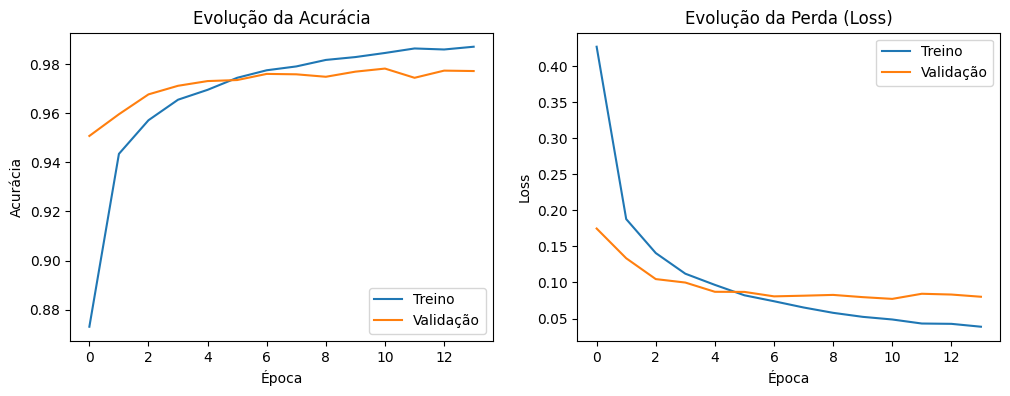

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_14296\4262572536.py:92: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  plt.savefig('imagens/matriz_confusao.png')
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


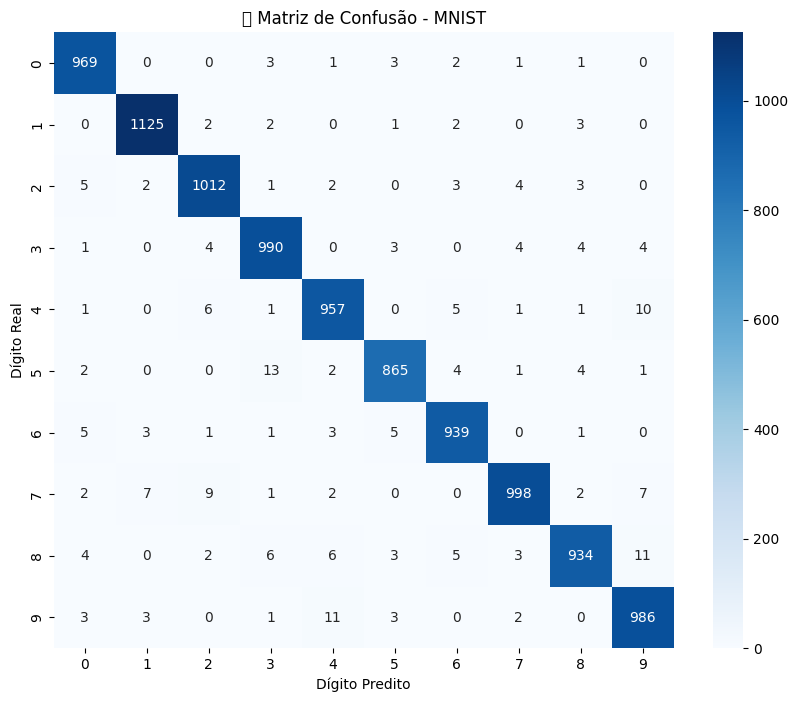


Exibindo alguns exemplos onde o modelo errou:


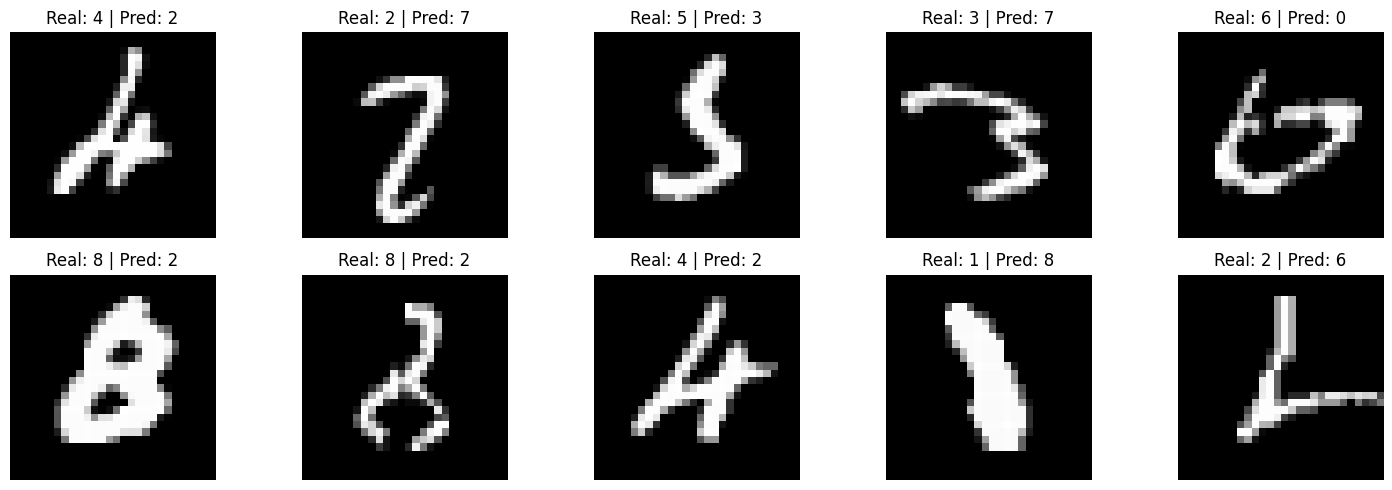


✅ Script finalizado. Modelo salvo como 'mnist_model.h5' e gráficos em '/imagens'.


In [1]:
# 🔧 Importações principais
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Configuração de ambiente e carregamento do dataset
os.makedirs('imagens', exist_ok=True) # Garante que a pasta para os gráficos exista

mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Pré-processamento e Normalização Explícita
# Escalonamos os pixels de 0-255 para 0.0-1.0
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# 3. Definição da Arquitetura (Rede Neural Densa com Dropout)
model = keras.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Técnica para evitar que a rede "decore" os dados
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Usamos 'sparse_categorical_crossentropy' para não precisar converter y com to_categorical
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Treinamento com Early Stopping
# Interrompe o treino se a perda de validação parar de melhorar por 3 épocas
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

print("Iniciando treinamento...")
history = model.fit(
    x_train, y_train, 
    epochs=15, 
    batch_size=128,
    validation_split=0.2, 
    verbose=1,
    callbacks=[early_stop]
)

# 5. Avaliação Final e Métricas
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nAcurácia final no teste: {acc:.2%}")
print(f"Loss final: {loss:.4f}")

# 6. Gráficos de Desempenho
plt.figure(figsize=(12, 4))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.savefig('imagens/desempenho_modelo.png')
plt.show()

# 7. Matriz de Confusão (Análise de Erro)
y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('🔢 Matriz de Confusão - MNIST')
plt.ylabel('Dígito Real')
plt.xlabel('Dígito Predito')
plt.savefig('imagens/matriz_confusao.png')
plt.show()

# 8. Visualização de Erros Específicos
def visualizar_erros(x, y_true, y_pred, n=10):
    indices_erros = np.where(y_pred != y_true)[0]
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices_erros[:n]):
        plt.subplot(2, 5, i+1)
        plt.imshow(x[idx], cmap='gray')
        plt.title(f"Real: {y_true[idx]} | Pred: {y_pred[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nExibindo alguns exemplos onde o modelo errou:")
visualizar_erros(x_test, y_test, y_pred)

# 9. Exportação do Modelo para Deploy
model.save('mnist_model.h5')
print("\n✅ Script finalizado. Modelo salvo como 'mnist_model.h5' e gráficos em '/imagens'.")